# Hospital Readmission Prediction

Predicting 30-day hospital readmission using L2-regularized Logistic Regression.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

sns.set_theme(style="whitegrid")

In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()

zip_file = next(iter(uploaded))

with zipfile.ZipFile(zip_file, "r") as z:
    z.extractall("/content/hospital_data")

print("Dataset extracted successfully.")

Saving Hospital_diabetes.zip to Hospital_diabetes.zip
Dataset extracted successfully.


In [ ]:
import os

for root, dirs, files in os.walk("/content/hospital_data"):
    for file in files:
        print(os.path.join(root, file))

/content/hospital_data/diabetic_data.csv
/content/hospital_data/description.pdf


In [ ]:
df = pd.read_csv("/content/hospital_data/diabetic_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
print(df.isnull().sum().sort_values(ascending=False).head(15))
print("\nDuplicates:", df.duplicated().sum())

max_glu_serum               96420
A1Cresult                   84748
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
dtype: int64

Duplicates: 0


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


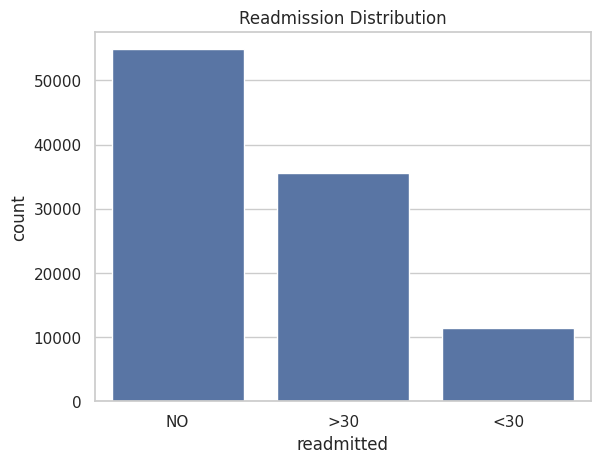

In [ ]:
print(df["readmitted"].value_counts())

sns.countplot(x="readmitted", data=df)
plt.title("Readmission Distribution")
plt.show()

In [ ]:
df["target"] = (df["readmitted"] == "<30").astype(int)

print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(3))

target
0    90409
1    11357
Name: count, dtype: int64
target
0    0.888
1    0.112
Name: proportion, dtype: float64


In [ ]:
features = [
    "age",
    "gender",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "diag_1",
    "diag_2",
    "diag_3",
    "max_glu_serum",
    "A1Cresult"
]

X = df[features]
y = df["target"]

print(X.shape)

(101766, 15)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (81412, 15)
Test : (20354, 15)


In [ ]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_features = [
    "age",
    "gender",
    "diag_1",
    "diag_2",
    "diag_3",
    "max_glu_serum",
    "A1Cresult"
]

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.6436
Precision: 0.1666
Recall   : 0.5482
F1 Score : 0.2555
ROC-AUC  : 0.639


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Readmitted", "Readmitted"]
))

                precision    recall  f1-score   support

Not Readmitted       0.92      0.66      0.77     18083
    Readmitted       0.17      0.55      0.26      2271

      accuracy                           0.64     20354
     macro avg       0.54      0.60      0.51     20354
  weighted avg       0.84      0.64      0.71     20354



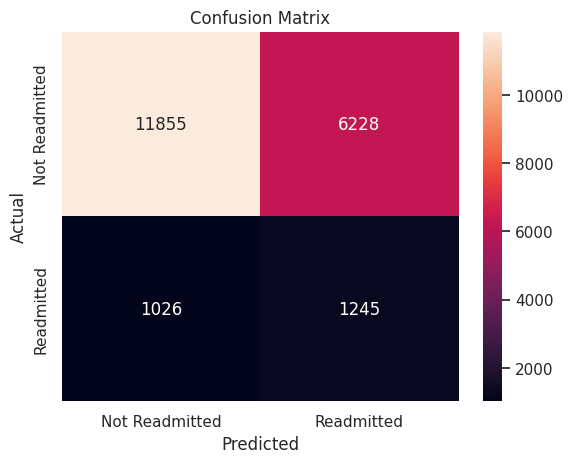

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

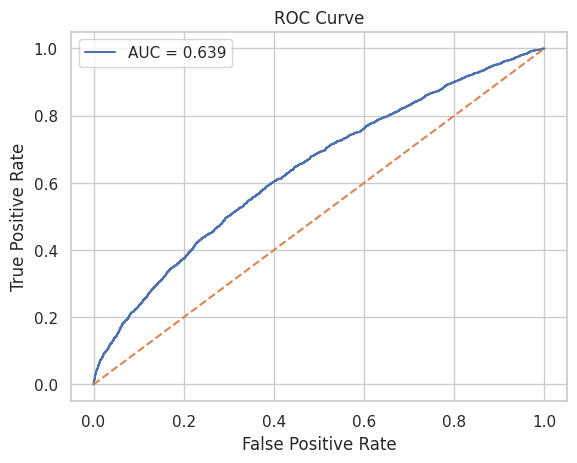

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred = (y_prob >= t).astype(int)

    print(
        "Threshold:", t,
        "| Precision:", round(precision_score(y_test, pred), 3),
        "| Recall:", round(recall_score(y_test, pred), 3)
    )

Threshold: 0.3 | Precision: 0.12 | Recall: 0.929
Threshold: 0.4 | Precision: 0.135 | Recall: 0.789
Threshold: 0.5 | Precision: 0.167 | Recall: 0.548
Threshold: 0.6 | Precision: 0.208 | Recall: 0.306
Threshold: 0.7 | Precision: 0.265 | Recall: 0.143


In [ ]:
fn_cost = 5
fp_cost = 1

for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred = (y_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    cost = (fn * fn_cost) + (fp * fp_cost)

    print(
        "Threshold:", t,
        "| False Negatives:", fn,
        "| False Positives:", fp,
        "| Cost:", cost
    )

Threshold: 0.3 | False Negatives: 161 | False Positives: 15450 | Cost: 16255
Threshold: 0.4 | False Negatives: 480 | False Positives: 11451 | Cost: 13851
Threshold: 0.5 | False Negatives: 1026 | False Positives: 6228 | Cost: 11358
Threshold: 0.6 | False Negatives: 1575 | False Positives: 2653 | Cost: 10528
Threshold: 0.7 | False Negatives: 1946 | False Positives: 900 | Cost: 10630


In [ ]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Impact"] = coef_df["Coefficient"].abs()

display(
    coef_df.sort_values("Impact", ascending=False).head(15)
)

,Feature,Coefficient,Impact
1232,cat__diag_2_807,-2.106981,2.106981
1539,cat__diag_3_250.91,2.017289,2.017289
231,cat__diag_1_356,2.011794,2.011794
1827,cat__diag_3_602,2.000661,2.000661
460,cat__diag_1_643,1.964075,1.964075
1776,cat__diag_3_537,-1.940194,1.940194
462,cat__diag_1_646,1.926049,1.926049
970,cat__diag_2_429,-1.900584,1.900584
2180,cat__diag_3_V60,1.895355,1.895355
1925,cat__diag_3_736,-1.843262,1.843262


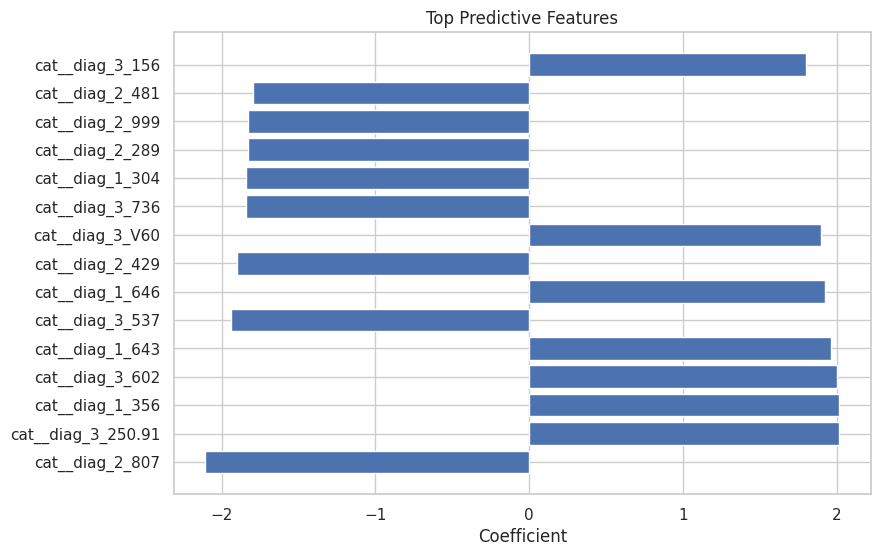

In [ ]:
top = coef_df.sort_values("Impact", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(top["Feature"], top["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top Predictive Features")
plt.show()

In [ ]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0, 1]

print(
    "Prediction:",
    "Readmitted within 30 days" if prediction == 1
    else "Not readmitted within 30 days"
)

print("Readmission risk:", round(probability * 100, 2), "%")

Prediction: Readmitted within 30 days
Readmission risk: 57.93 %


## Clinical Cost

A false negative misses a patient who is readmitted.

A false positive creates an unnecessary alert.

The prediction threshold should consider the relative cost of these two errors.

## Limitations

- The dataset is specific to diabetic patients.
- Model performance depends on the available patient information.
- The model should support screening, not replace clinical judgment.

## Conclusion

L2-regularized Logistic Regression was used to predict 30-day readmission risk.

ROC-AUC, precision, recall, confusion matrix, and clinical cost were used for evaluation.